In [2]:
import importlib.util
import subprocess
import sys


def in_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False


IN_COLAB = in_colab()
print(f"Running in Colab: {IN_COLAB}")

REQUIRED_PACKAGES = [
    ("langchain", "langchain"),
    ("langchain_openai", "langchain-openai"),
    ("langchain_qdrant", "langchain-qdrant"),
    ("langchain_community", "langchain-community"),
    ("langchain_text_splitters", "langchain-text-splitters"),
    ("qdrant_client", "qdrant-client"),
]


def ensure_packages(required):
    missing = []
    for module_name, package_name in required:
        if importlib.util.find_spec(module_name) is None:
            missing.append(package_name)
    if missing:
        if IN_COLAB:
            print("Installing missing packages:", " ".join(missing))
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])
        else:
            raise ModuleNotFoundError(
                f"Missing packages: {', '.join(missing)}. Install them with `pip install {' '.join(missing)}` before continuing."
            )
    else:
        print("All required packages found.")


ensure_packages(REQUIRED_PACKAGES)


Running in Colab: False
All required packages found.


# Creando y usando BBDDs vectoriales en produccion. Ejemplo de Qdrant Cloud

## Conceptos clave (antes de empezar)

- **Embedding**: una representación numérica (un vector) de un texto. Textos con
  significado parecido quedan "cerca" en ese espacio vectorial.
- **Chunking**: partir un documento largo en trozos (*chunks*) más pequeños antes de
  generar sus embeddings. Así la búsqueda recupera fragmentos relevantes y no documentos enteros.
- **Base de datos vectorial (Qdrant)**: almacena los vectores y permite buscar por
  *similitud* (vecinos más cercanos), en vez de por coincidencia exacta de palabras.

Flujo de este notebook: leer documento -> *chunking* -> embeddings -> cargar en Qdrant -> consultar por similitud.


Paso 1: Generar un cluster y sacar su API KEY y URL

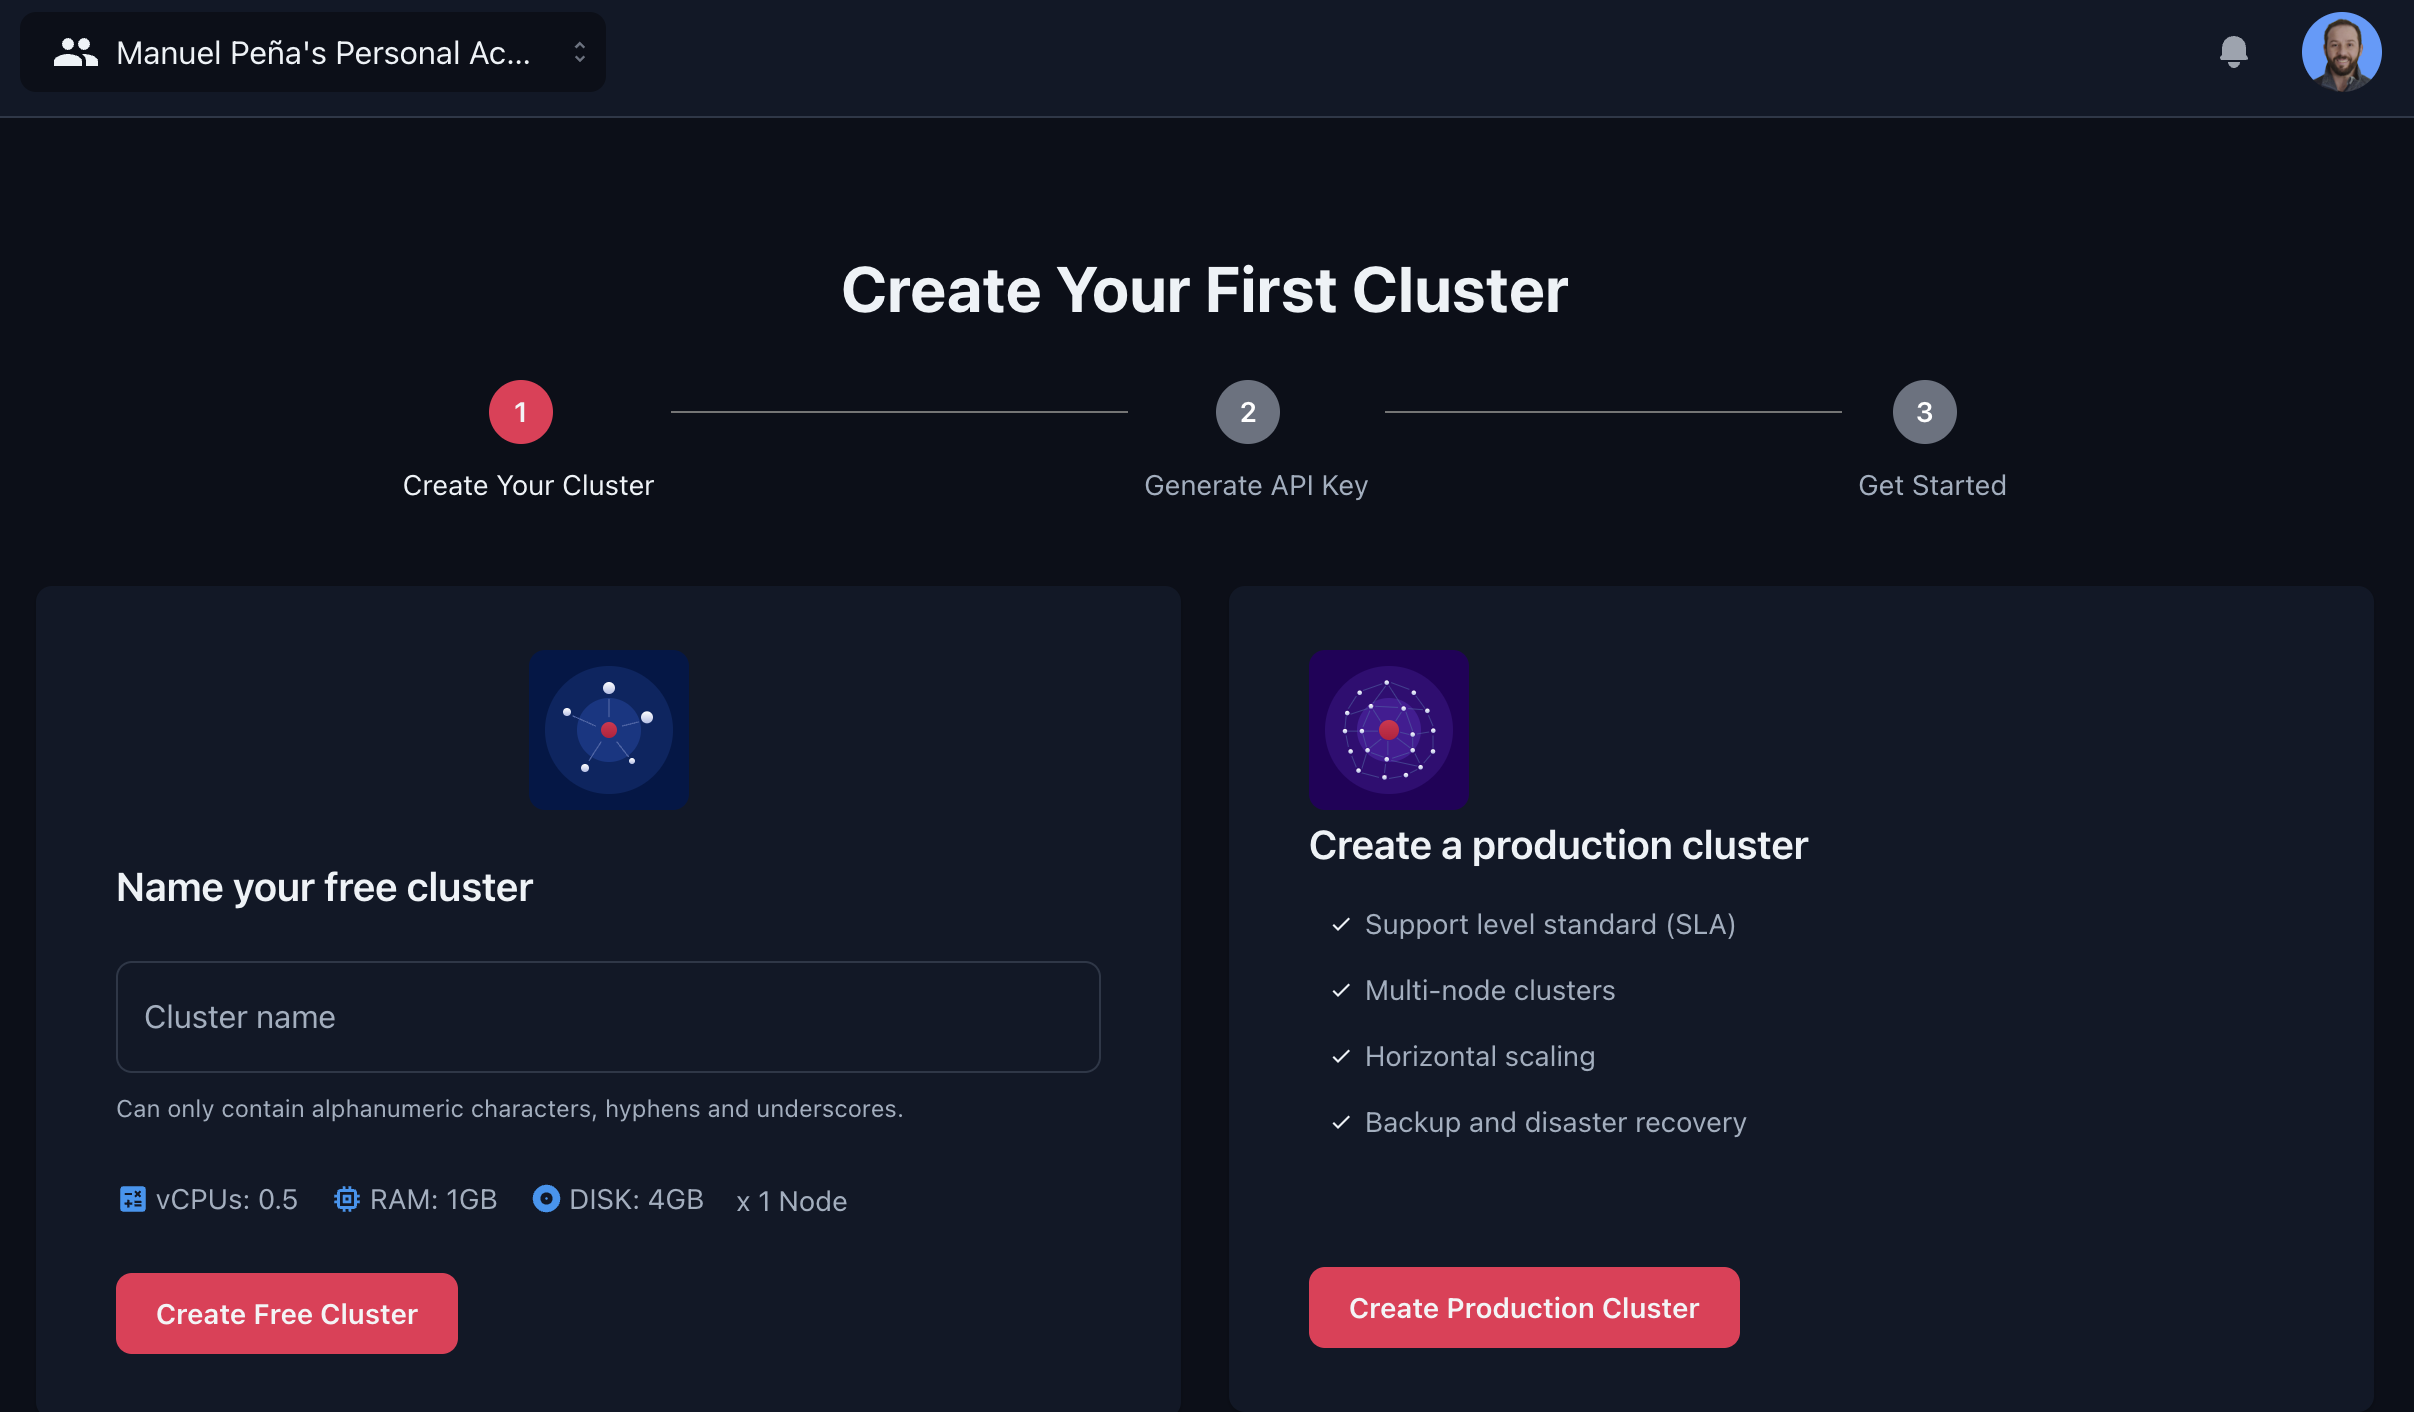

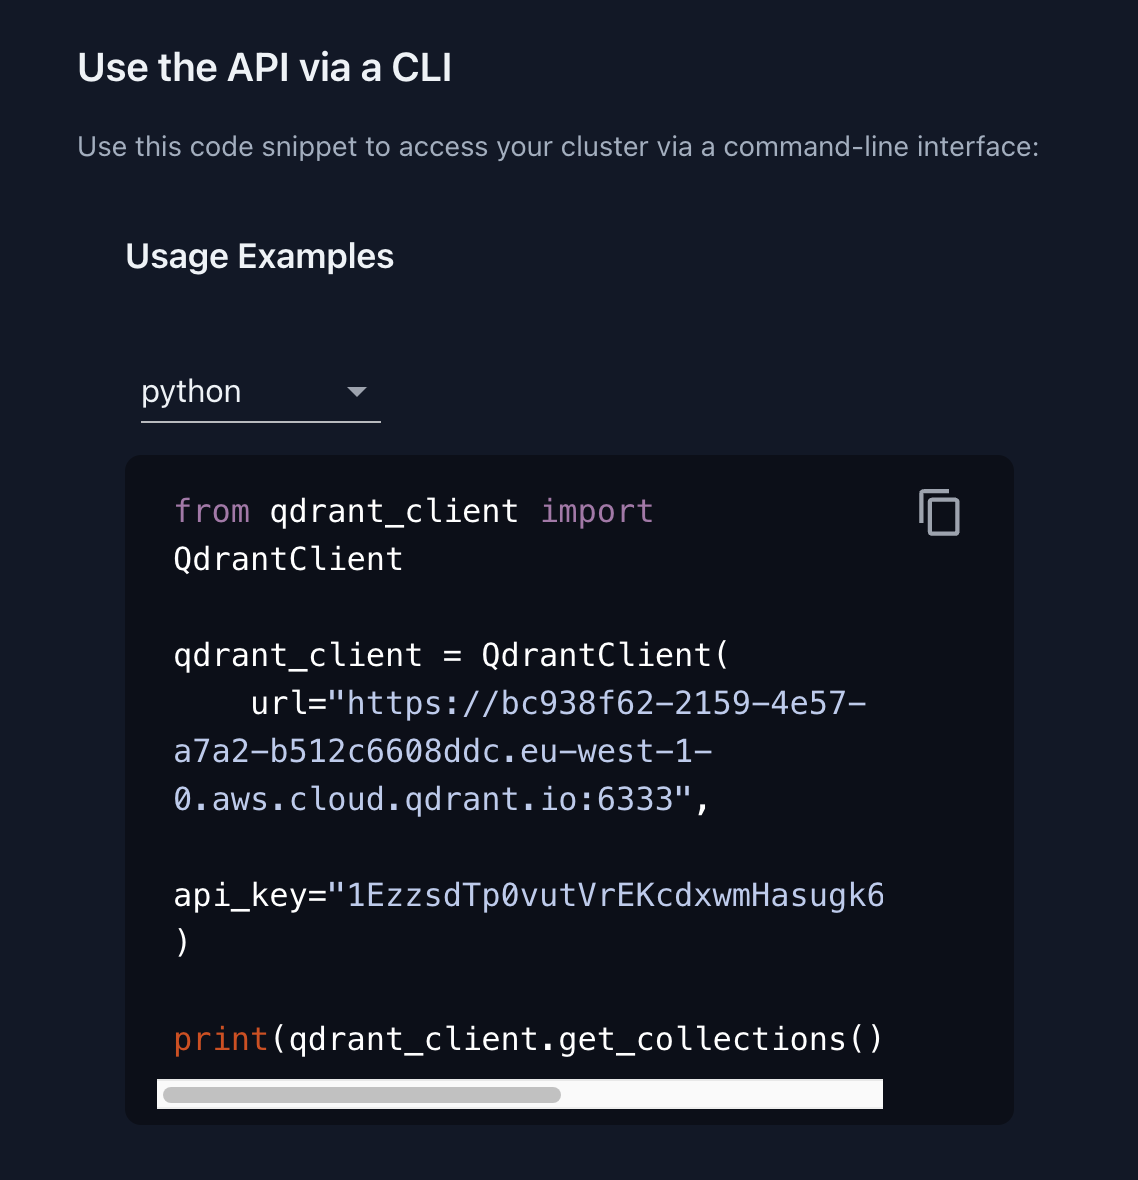

In [2]:
import os
from pathlib import Path

if IN_COLAB:
    from google.colab import userdata  # type: ignore

    # Guardamos las credenciales directamente en Colab
    qdrant_api_key = userdata.get("QDRANT_API_KEY")
    qdrant_url = userdata.get("QDRANT_URL")
    openai_api_key = userdata.get("OPENAI_API_KEY")
else:
    # Look for a .env in this lesson folder, then the class root (class_3_5_deployment/.env)
    env_path = next((p for p in (Path(".env"), Path("../.env")) if p.exists()), None)
    if env_path is not None:
        print(f"Loading environment variables from {env_path}")
        with env_path.open() as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                os.environ.setdefault(key, value)
    else:
        print("No .env found; relying on existing environment variables.")

    qdrant_api_key = os.getenv("QDRANT_API_KEY")
    qdrant_url = os.getenv("QDRANT_URL")
    openai_api_key = os.getenv("OPENAI_API_KEY")

required_vars = {"QDRANT_API_KEY": qdrant_api_key, "QDRANT_URL": qdrant_url}
missing_env = [key for key, value in required_vars.items() if not value]
if missing_env:
    raise EnvironmentError(f"Missing required environment variables: {', '.join(missing_env)}")

if not openai_api_key:
    print("Warning: OPENAI_API_KEY not set. Embedding creation will fail until it is provided.")


Loading environment variables from .env


Paso 2: Cargar documentos al cluster.

Primero vamos a tomar documentos y cargarlos con sus embeddings correspondientes


In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

with open("trump_speech.txt") as f:
    trump_speech = f.read()

# chunk_size  = máximo de caracteres por chunk
# chunk_overlap = caracteres que se repiten entre chunks contiguos, para no perder
#                 contexto cuando una idea queda cortada en el límite de un chunk.
# RecursiveCharacterTextSplitter es el baseline recomendado: intenta cortar primero
# por párrafos, luego líneas, luego palabras, manteniendo los chunks coherentes.
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

texts = text_splitter.create_documents([trump_speech])

print(f"El documento se dividió en {len(texts)} chunks")
for text in texts:
    print(text)
    print("---")


page_content='﻿Vice President Vance, Speaker Johnson, Senator Thune, Chief Justice Roberts, justices of the United States Supreme Court, President Clinton, President Bush, President Obama, President Biden, Vice President Harris and my fellow citizens:
The golden age of America begins right now. From this day forward, our country will flourish and be respected again all over the world. We will be the envy of every nation. And we will not allow ourselves to be taken advantage of any longer.
During every single day of the Trump administration, I will, very simply, put America first. Our sovereignty will be reclaimed. Our safety will be restored. The scales of justice will be rebalanced. The vicious, violent and unfair weaponization of the Justice Department and our government will end. And our top priority will be to create a nation that is proud and prosperous and free.
America will soon be greater, stronger, and far more exceptional than ever before. I return to the presidency confident

In [4]:
from langchain_qdrant import QdrantVectorStore
from langchain_openai import OpenAIEmbeddings

if not openai_api_key:
    raise ValueError("OPENAI_API_KEY is required to create embeddings.")

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-large",
    openai_api_key=openai_api_key,
)

qdrant = QdrantVectorStore.from_documents(
    texts,
    embeddings,
    url=qdrant_url,
    api_key=qdrant_api_key,
    prefer_grpc=False,
    collection_name="trump_speech",
    force_recreate=True,
)


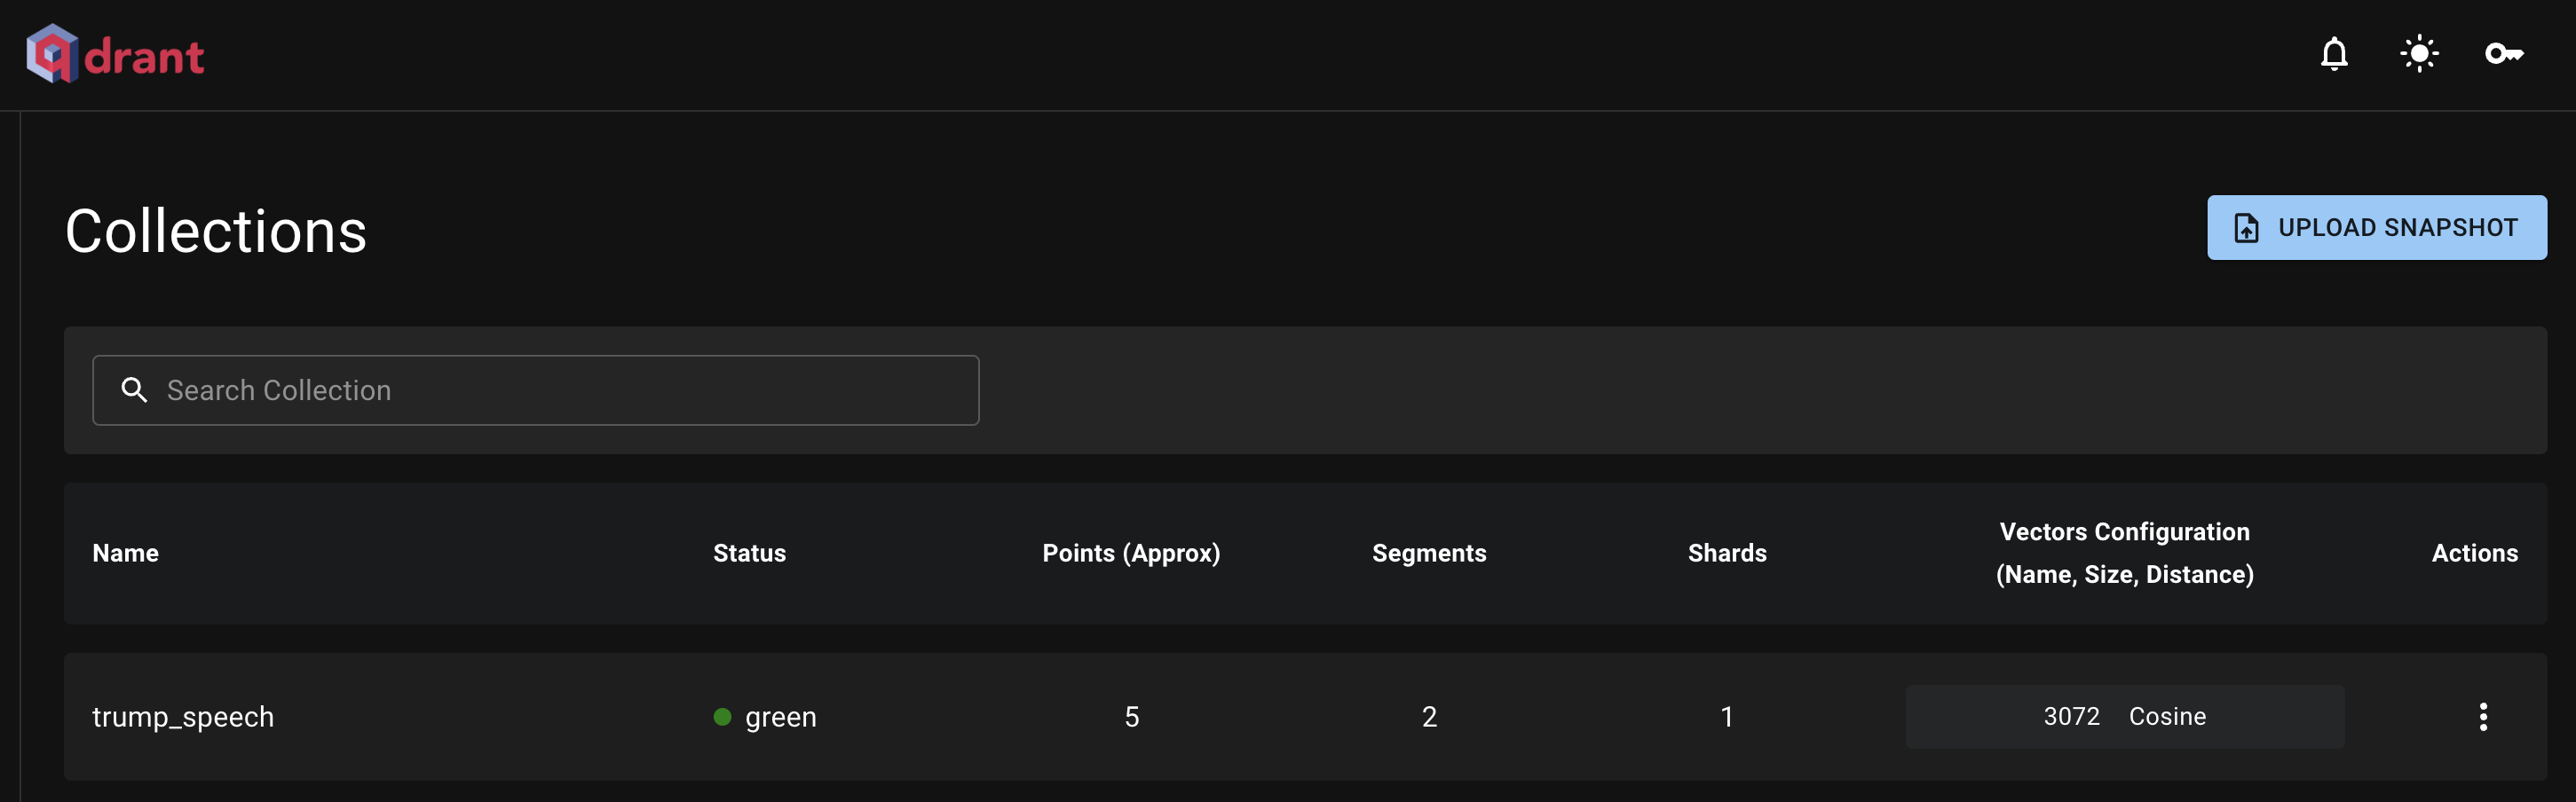

Paso 3: Usar la coleccion ya existente

In [5]:
qdrant = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name="trump_speech",
    url=qdrant_url,
    api_key=qdrant_api_key
)

query = "What did the president say about the Panama Canal?"
found_docs = qdrant.similarity_search(query)

for doc in found_docs:
  print(doc)
  print('----')

page_content='He was a natural businessman and gave Teddy Roosevelt the money for many of the great things he did, including the Panama Canal, which has foolishly been given to the country of Panama after the United States — the United States, I mean, think of this, spent more money than ever spent on a project before and lost 38,000 lives in the building of the Panama Canal. We have been treated very badly from this foolish gift that should have never been made. And Panama's promise to us has been broken. The purpose of our deal and the spirit of our treaty has been totally violated. American ships are being severely overcharged and not treated fairly in any way, shape or form, and that includes the United States Navy. And above all, China is operating the Panama Canal. And we didn't give it to China, we gave it to Panama, and we're taking it back.
Above all, my message to Americans today is that it is time for us to once again act with courage, vigor and the vitality of history's gre